In [12]:
import torch
import os
import json
import random
import data_utils
import cbm

load_dir = "saved_models/places365_lf_cbm"
device = "cuda"

model = cbm.load_cbm(load_dir, device)

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)

_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
val_data_t = data_utils.get_data("places365_val", preprocess=target_preprocess)
val_pil_data = data_utils.get_data("places365_val")

cls_file = data_utils.LABEL_FILES["places365"]
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

print(f"Loaded {len(classes)} classes, {len(concepts)} concepts")

Loaded 365 classes, 2207 concepts


In [2]:
# import sys
# !{sys.executable} -m pip install diffusers

In [13]:
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
import torch

pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    "timbrooks/instruct-pix2pix",
    torch_dtype=torch.float16,
    safety_checker=None
)
pipe = pipe.to("cuda")
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [14]:
# Build this once after loading val_pil_data
from collections import defaultdict

label_to_indices = defaultdict(list)
for i in range(len(val_pil_data)):
    label = val_pil_data.targets[i]  # or val_pil_data.imgs[i][1] for ImageFolder
    label_to_indices[label].append(i)

def get_places365_image(class_name, image_id=None):
    class_idx = classes.index(class_name)
    i = image_id if image_id is not None else random.choice(label_to_indices[class_idx])
    image, label = val_pil_data[i]
    return image, i

  0%|          | 0/100 [00:00<?, ?it/s]

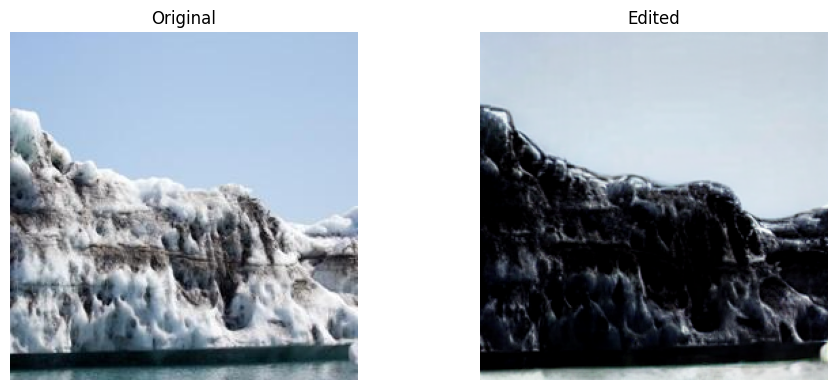

In [15]:
def edit_image(image, prompt, image_guidance_scale=1.5, guidance_scale=7.5):
    edited = pipe(
        prompt,
        image=image,
        image_guidance_scale=image_guidance_scale,
        guidance_scale=guidance_scale,
    ).images[0]
    return edited

random.seed(40)
img, img_id = get_places365_image("iceberg")
edited = edit_image(img, "remove black ice", guidance_scale=12.5, image_guidance_scale=2.5)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title("Original")
axes[1].imshow(edited)
axes[1].axis("off")
axes[1].set_title("Edited")
plt.tight_layout()
plt.show()

In [17]:
def edit_image_from_paths(image_paths, prompt, image_guidance_scale=1.5, guidance_scale=7.5):
    if not isinstance(image_paths, list):
        image_paths = [image_paths]

    for path in image_paths:
        image = Image.open(path).convert("RGB")
        edited = edit_image(image, prompt, image_guidance_scale=image_guidance_scale, guidance_scale=guidance_scale)

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(image)
        axes[0].axis("off")
        axes[0].set_title(f"Original\n{Path(path).name}")
        axes[1].imshow(edited)
        axes[1].axis("off")
        axes[1].set_title(f"Edited\n{prompt}")
        plt.tight_layout()
        plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

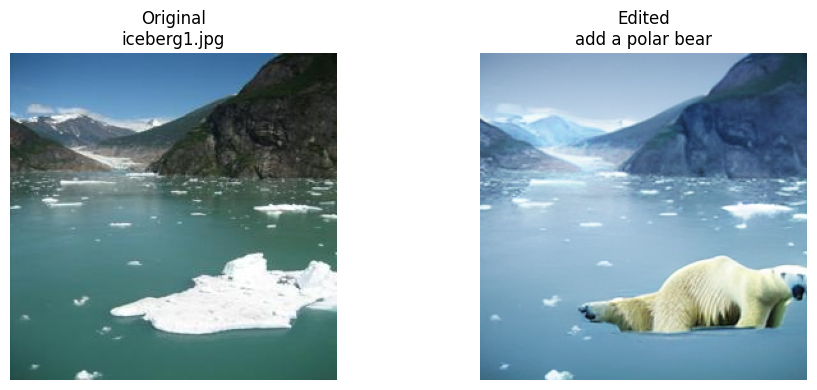

  0%|          | 0/100 [00:00<?, ?it/s]

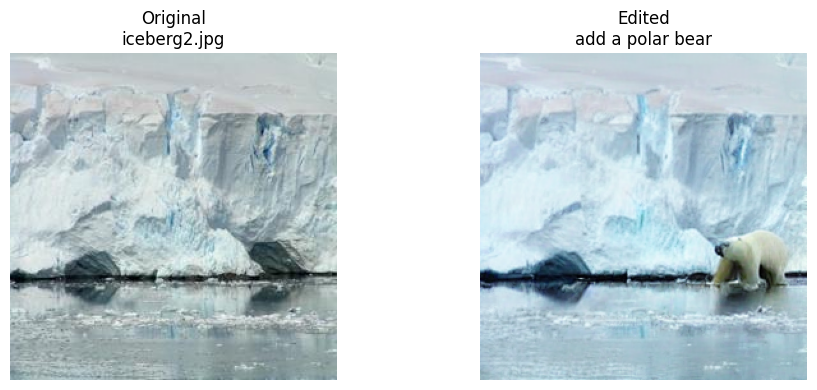

  0%|          | 0/100 [00:00<?, ?it/s]

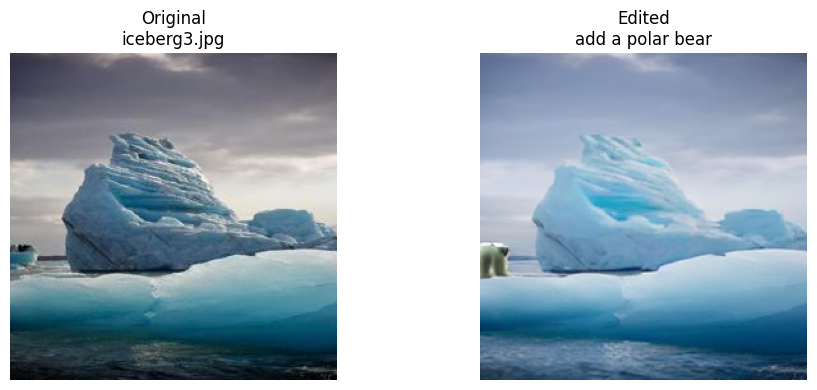

In [24]:
from PIL import Image
from pathlib import Path

# multiple images
edit_image_from_paths(
    ["iceberg_seed10/iceberg1.jpg", "iceberg_seed10/iceberg2.jpg", "iceberg_seed10/iceberg3.jpg"],
    "add a polar bear",
    guidance_scale=12.5,
    image_guidance_scale=1.5,
)